In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

URL='http://fpaniaguapython.github.io/datos/CCAA-ULTIMOS-DOCE-MESES-LAPTOP-H55DSDJ2-2026-09.csv'

datos = pd.read_csv(URL, sep=';', decimal=',', thousands='.')

datos

,comunidad,oct-25,nov-25,dic-25,ene-26,feb-26,mar-26,abr-26,may-26,jun-26,jul-26,ago-26,sep-26
0,Total,96784,94124,103011,73105,97083,130339,106862,111895,128424,101949,68544,93858
1,ANDALUCIA,10560,10035,10497,7731,9201,11510,9708,10114,11910,11157,8364,10903
2,ARAGON,1726,1668,1816,1206,1537,1746,1531,1721,2101,1958,1328,1865
3,ASTURIAS,1475,1533,1454,916,1047,1404,1072,1439,1627,1348,1999,1598
4,CANARIAS,5581,5749,4090,2713,2608,5223,3290,3462,5507,6047,3244,3748
5,CANTABRIA,931,781,930,655,762,858,744,867,1008,865,862,970
6,CASTILLA Y LEON,2584,2539,2761,1975,2123,2698,2341,2421,2752,2574,2092,2515
7,CASTILLA-LA MANCHA,3149,2522,2596,1874,2222,2708,2157,2588,2656,2883,2166,2758
8,CATALUÑA,13080,12771,12203,9435,11134,13770,11831,12482,14903,12701,8529,12873
9,CEUTA,105,93,81,68,74,89,76,90,88,110,63,62


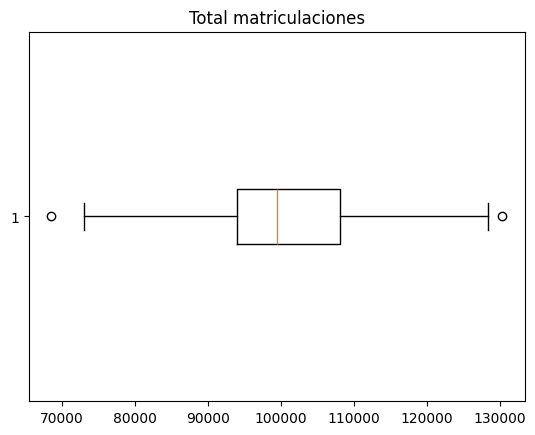

In [7]:
# Total de matriculaciones

#plt.boxplot(datos.loc[0][1:], orientation='horizontal')
plt.boxplot(datos.iloc[0,1:], orientation='horizontal')
plt.title("Total matriculaciones")
plt.show()

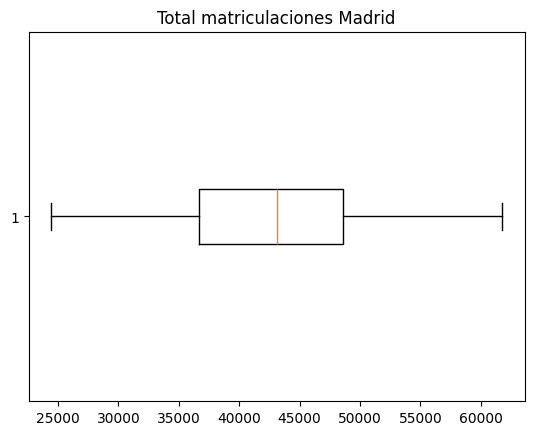

In [8]:
# Total de Madrid
nombre_comunidad = 'COMUNIDAD DE MADRID'
#plt.boxplot(datos.iloc[10,1:], orientation='horizontal')

plt.title("Total matriculaciones Madrid")
plt.show()

In [ ]:
# Por meses

plt.boxplot(datos.iloc[1:,1:], orientation='horizontal')
plt.title("Total ventas")
plt.ylabel("CCAA")

plt.yticks(
    range(12), # Posiciones
    datos.columns[1:] # Valores
)

plt.show()

In [ ]:
# Por comunidades

plt.boxplot(datos.T.iloc[1:,1:], orientation='horizontal')
plt.title("Total matriculaciones")
plt.ylabel("CCAA")

plt.yticks(
    range(1, len(datos.iloc[1:]) + 1), # Posiciones
    datos.iloc[1:, 0] # Valores
)

plt.show()

In [ ]:
datos.head()

In [ ]:
# Por comunidades excluyendo las que matriculan muchos

#UMBRAL_ACUMULADO = np.inf
UMBRAL_ACUMULADO = 100_000

resultado = datos[datos[datos.columns[1:]].sum(axis=1) < UMBRAL_ACUMULADO]

plt.boxplot(resultado.T.iloc[1:,1:], orientation='horizontal')

plt.title("Total matriculaciones")
plt.ylabel("CCAA")

plt.yticks(
    range(1, len(resultado)), # Posiciones
    resultado['comunidad'][1:] # Valores
)

plt.show()


In [ ]:
# Ordenación

# Por columna
# datos.sort_values(by='comunidad', inplace=True)

# Ordenar por acumulados
# datos = datos.loc[datos.iloc[:, 1:].sum(axis=1).sort_values(ascending=False).index]

# Ordenar por acumulados en dos pasos
datos['acumulado'] = datos.iloc[:,1:].sum(axis=1)
datos = datos.sort_values(by='acumulado',  ascending=False).drop(columns=['acumulado'])

display(datos)